# 1C Sales prediction

## Part 2: Model training and submission

In [1]:
import numpy as np
import pandas as pd
import dateutil
import datetime as dt
from datetime import date
from pandarallel import pandarallel
import matplotlib.pyplot as plt
import seaborn as sns
import re
import gc
from tqdm.notebook import tqdm
import pickle

from itertools import permutations, product

import lightgbm as lgb

from lightgbm import LGBMRegressor
from lofo import LOFOImportance, FLOFOImportance, Dataset, plot_importance

from sklearn.metrics import (mean_squared_log_error, mean_squared_error,
                             mean_absolute_error)
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

from sklearn.model_selection import train_test_split, KFold
import warnings

## Data preparation

In [2]:
alles = pd.read_pickle('data/alles_final.pkl')
alles = alles.drop(['mean_price', 'av_shop_item'], axis=1)

In [3]:
rows = alles['date_block_num'] > 11

In [57]:
new_features = pd.read_pickle('data/new_features.pkl')

In [14]:
alles[['item_name', 'item_category', 'item_subcategory', 'city', 'shop_type']] = \
alles[['item_name', 'item_category',
       'item_subcategory', 'city', 'shop_type']].apply(LabelEncoder().fit_transform)

In [58]:
features = list(new_features) + ['date_block_num']
cols = list(features)+['item_cnt_month']

In [59]:
data = alles.loc[rows, cols]
data = data.fillna(0)

In [17]:
train_rows = data.date_block_num < 33
test_rows = data.date_block_num == 33

In [18]:
X_train = data[train_rows].drop(['item_cnt_month'], axis=1)
y_train = data[train_rows]['item_cnt_month']
X_test = data[test_rows].drop(['item_cnt_month'], axis=1)
y_test = data[test_rows]['item_cnt_month']

X_final_test = data[data.date_block_num == 34].drop(['item_cnt_month'], axis=1)

## Model

### Cross-validation ensemble

Selecting "proper" categorical features:

In [19]:
categorical_features = (data.dtypes[data.dtypes.apply(str).str.startswith('int')].index).tolist()

In [20]:
categorical_features

['item_first_sale',
 'item_category_id',
 'first_sale',
 'item_subcategory',
 'item_category',
 'shop_type',
 'city',
 'shop_first_sale',
 'shop_id',
 'shop_item_active_months_lag_1',
 'active_months_lag_1',
 'date_block_num']

In [21]:
categorical_features = ['item_category_id',
 'shop_id']

In [22]:
params = pd.read_pickle('data/final_params.pkl')

Training the LGBM models on 5 separate folds and using their average prediction for the final submission (y_final_test): 

In [23]:
kf = KFold(n_splits = 5, random_state=42)
resu1 = 0
impor1 = 0
resu3_mae=0
y_pred = 0
y_final_test = 0
stack_train = np.zeros([X_train.shape[0], ])
models = []
for train_index, test_index in tqdm(list(kf.split(X_train, y_train))):
    X_train2 = X_train.iloc[train_index, :]
    y_train2 = y_train.iloc[train_index]
    X_test2 = X_train.iloc[test_index, :]
    y_test2 = y_train.iloc[test_index]
    
    d_training = lgb.Dataset(X_train2, label=y_train2,
                             categorical_feature=categorical_features,
                             free_raw_data=False)
    d_test = lgb.Dataset(X_test2, label=y_test2,
                         categorical_feature=categorical_features,
                         free_raw_data=False)
    
    clf = lgb.train(params, train_set=d_training, num_boost_round=1000,
                      valid_sets=[d_training, d_test], verbose_eval=25,
                      early_stopping_rounds=50)

    models.append(clf)
    temp_predict = clf.predict(X_test2, num_iteration=clf.best_iteration)
    stack_train[test_index] = temp_predict

    y_pred += clf.predict(X_test, num_iteration=clf.best_iteration)/5
    y_final_test += clf.predict(X_final_test, num_iteration=clf.best_iteration)/5
    mse = mean_squared_error(y_test2, temp_predict)
    mae = mean_absolute_error(y_test2, temp_predict)

    resu1 += mse/5
    resu3_mae += mae/5 
    impor1 += clf.feature_importance()/5
    del X_train2, y_train2, X_test2, y_test2; gc.collect()

/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/lightgbm/basic.py:1291: UserWarning: Using categorical_feature in Dataset.
  warnings.warn('Using categorical_feature in Dataset.')


Training until validation scores don't improve for 50 rounds
[25]	training's rmse: 0.785047	valid_1's rmse: 0.814708
[50]	training's rmse: 0.75325	valid_1's rmse: 0.811764
[75]	training's rmse: 0.738236	valid_1's rmse: 0.810117
[100]	training's rmse: 0.728403	valid_1's rmse: 0.810355
[125]	training's rmse: 0.72199	valid_1's rmse: 0.810222
Early stopping, best iteration is:
[87]	training's rmse: 0.733471	valid_1's rmse: 0.809776


/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/lightgbm/basic.py:1291: UserWarning: Using categorical_feature in Dataset.
  warnings.warn('Using categorical_feature in Dataset.')


Training until validation scores don't improve for 50 rounds
[25]	training's rmse: 0.804927	valid_1's rmse: 0.741018
[50]	training's rmse: 0.771542	valid_1's rmse: 0.726706
[75]	training's rmse: 0.754692	valid_1's rmse: 0.721708
[100]	training's rmse: 0.744846	valid_1's rmse: 0.720476
[125]	training's rmse: 0.738	valid_1's rmse: 0.719511
[150]	training's rmse: 0.731992	valid_1's rmse: 0.718897
[175]	training's rmse: 0.726735	valid_1's rmse: 0.718477
[200]	training's rmse: 0.721574	valid_1's rmse: 0.717995
[225]	training's rmse: 0.717915	valid_1's rmse: 0.717667
[250]	training's rmse: 0.714466	valid_1's rmse: 0.717596
[275]	training's rmse: 0.711021	valid_1's rmse: 0.717051
[300]	training's rmse: 0.707496	valid_1's rmse: 0.716875
[325]	training's rmse: 0.704467	valid_1's rmse: 0.716749
[350]	training's rmse: 0.701754	valid_1's rmse: 0.716268
[375]	training's rmse: 0.699174	valid_1's rmse: 0.716497
Early stopping, best iteration is:
[345]	training's rmse: 0.70238	valid_1's rmse: 0.716223

/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/lightgbm/basic.py:1291: UserWarning: Using categorical_feature in Dataset.
  warnings.warn('Using categorical_feature in Dataset.')


Training until validation scores don't improve for 50 rounds
[25]	training's rmse: 0.769573	valid_1's rmse: 0.900859
[50]	training's rmse: 0.739471	valid_1's rmse: 0.887497
[75]	training's rmse: 0.724395	valid_1's rmse: 0.886368
[100]	training's rmse: 0.714973	valid_1's rmse: 0.886549
Early stopping, best iteration is:
[66]	training's rmse: 0.728595	valid_1's rmse: 0.885215


/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/lightgbm/basic.py:1291: UserWarning: Using categorical_feature in Dataset.
  warnings.warn('Using categorical_feature in Dataset.')


Training until validation scores don't improve for 50 rounds
[25]	training's rmse: 0.775015	valid_1's rmse: 0.867299
[50]	training's rmse: 0.74705	valid_1's rmse: 0.861906
[75]	training's rmse: 0.731945	valid_1's rmse: 0.868285
Early stopping, best iteration is:
[44]	training's rmse: 0.750966	valid_1's rmse: 0.860065


/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/lightgbm/basic.py:1291: UserWarning: Using categorical_feature in Dataset.
  warnings.warn('Using categorical_feature in Dataset.')


Training until validation scores don't improve for 50 rounds
[25]	training's rmse: 0.798316	valid_1's rmse: 0.764829
[50]	training's rmse: 0.764907	valid_1's rmse: 0.759941
[75]	training's rmse: 0.748406	valid_1's rmse: 0.761187
Early stopping, best iteration is:
[43]	training's rmse: 0.770487	valid_1's rmse: 0.759638



LGBM feature importances:

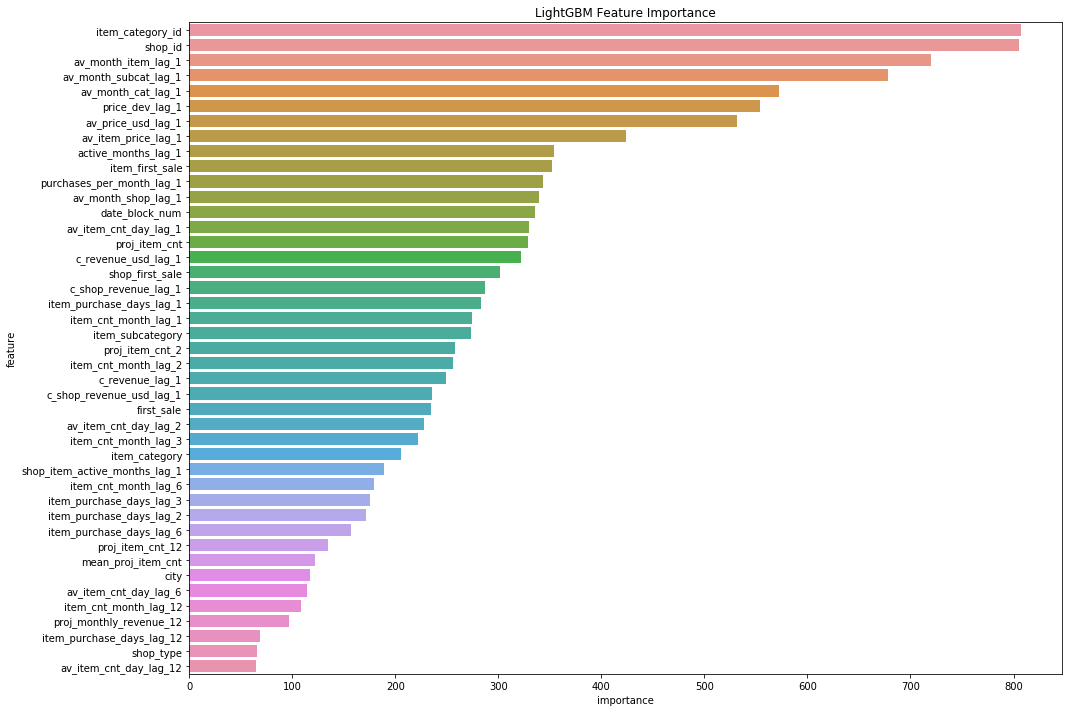

In [25]:
df_fimp = pd.DataFrame()
df_fimp["feature"] = X_train.columns.values
df_fimp["importance"] = impor1


plt.figure(figsize=(15, 10))
sns.barplot(x="importance", y="feature", data=df_fimp.sort_values(by="importance", ascending=False))
plt.title("LightGBM Feature Importance")
plt.tight_layout()

### Submission

In [26]:
test_df = pd.read_csv('data/test.csv')

In [27]:
submission = pd.DataFrame({
    "ID": test_df.index, 
    "item_cnt_month": y_final_test
})
submission.to_csv('lgbm_submission.csv', index=False)

In [32]:
submission.head()

,ID,item_cnt_month
0,0,0.560963
1,1,0.350374
2,2,1.074442
3,3,0.357301
4,4,3.092846


LB score = 0.903

### Interpreting the results:

Feature importances from LOFO:

In [33]:
importance_df = pd.read_pickle('data/feature_importances.pkl')

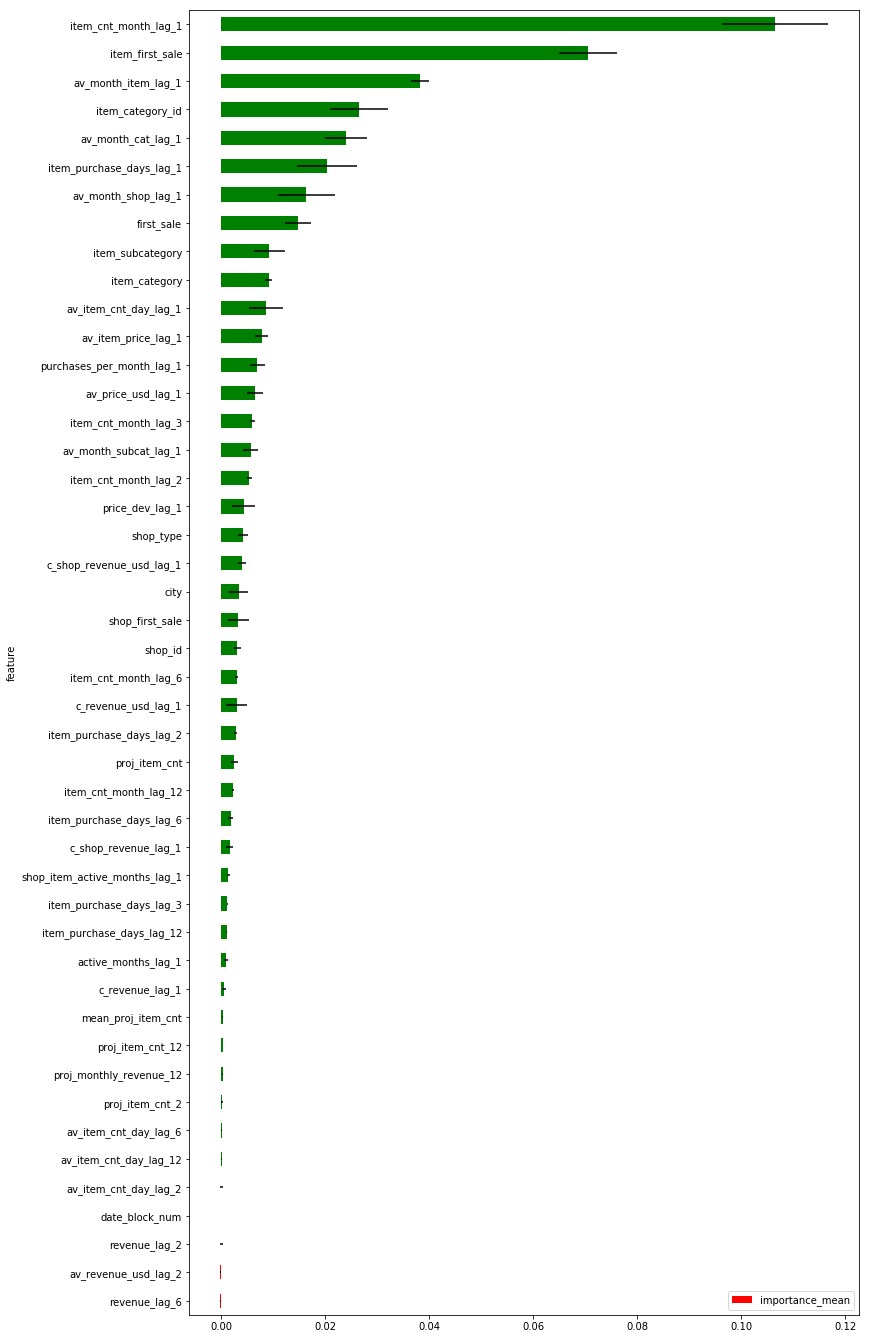

In [34]:
plot_importance(importance_df, figsize=(12,24))

Top features description:

1) __'item_cnt_month_lag_1'__ is the target variable value in the previous month;  
2) __'item_first_sale'__ is the number of months since the introduction of a particular item on the market;  
3) __'av_month_item_lag_1'__ is the value of the target varible in the previous month averaged over all the shops;  
4) __'item_category_id'__  
5) __'av_month_cat_lag_1'__ is the value of the target varible in the previous month averaged over the category_id of each item;  
6) __'item_purchase_days_lag_1'__ number of days (in a month) when a particular item is purchased in a particular shop. Basically, it is the target variable that does not take into account the exact number of items purchased per day (i.e. it's always considered 1)
7) __'av_month_shop_lag_1'__ is the value of the target varible in the previous month averaged over the shop_id of each item;  
8) __'first_sale'__ is the number of months since the appearance of a particular item in a particular shop;  

Overall, apart from the categorical features, the final prediction mostly relies in the market condition in the previous month. Two features that are different are 'item_first_sale' and 'first_sale':

In [63]:
group = alles.groupby(['shop_id', 'item_id'])

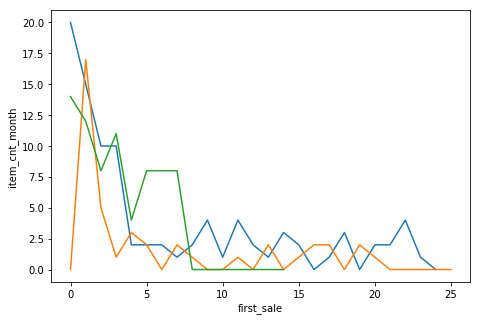

In [107]:
plt.figure(figsize=(7.5, 5))
plt.plot(group.get_group((59, 2269))['first_sale'], group.get_group((59, 2269))['item_cnt_month'])
plt.plot(group.get_group((59, 10298))['first_sale'], group.get_group((59, 10298))['item_cnt_month'])
plt.plot(group.get_group((59, 4164))['first_sale'], group.get_group((59, 4164))['item_cnt_month'])
plt.ylabel('item_cnt_month')
plt.xlabel('first_sale')
plt.show()

It seems that typically sales are high right after the item introduction and decay afterwards. So, by knowing how long ago an item first appeared on the market, one might tell something about the demand.

### A simpler model

As it can be seen, the score is heavily dominated by the __'item_cnt_month_lag_1'__ feature, i.e. the value of the target value in the previous month. So, it seems logical to build a minimalistic model based on this feature and other categorical ones, such as shop_id, item_category, etc.

In [35]:
r_features = ['item_cnt_month_lag_1', 'item_category_id', 'item_subcategory',
                   'item_category', 'shop_type', 'city', 'shop_id', 'date_block_num']

In [36]:
r_cols = list(r_features)+['item_cnt_month']

In [41]:
data = alles.loc[rows, r_cols]
data = data.fillna(0)

In [42]:
X_train = data[train_rows].drop(['item_cnt_month'], axis=1)
y_train = data[train_rows]['item_cnt_month']
X_test = data[test_rows].drop(['item_cnt_month'], axis=1)
y_test = data[test_rows]['item_cnt_month']

X_final_test = data[data.date_block_num == 34].drop(['item_cnt_month'], axis=1)

In [43]:
categorical_features = (data.dtypes[data.dtypes.apply(str).str.startswith('int')].index).tolist()

In [44]:
categorical_features

['item_category_id',
 'item_subcategory',
 'item_category',
 'shop_type',
 'city',
 'shop_id',
 'date_block_num']

In [45]:
categorical_features = ['item_category_id',
 'item_subcategory',
 'item_category',
 'shop_type',
 'city',
 'shop_id']

In [46]:
kf = KFold(n_splits = 5, random_state=42)
resu1 = 0
impor1 = 0
resu3_mae=0
y_pred = 0
y_final_test = 0
stack_train = np.zeros([X_train.shape[0], ])
models = []
for train_index, test_index in tqdm(list(kf.split(X_train, y_train))):
    X_train2 = X_train.iloc[train_index, :]
    y_train2 = y_train.iloc[train_index]
    X_test2 = X_train.iloc[test_index, :]
    y_test2 = y_train.iloc[test_index]
    
    d_training = lgb.Dataset(X_train2, label=y_train2,
                             categorical_feature=categorical_features,
                             free_raw_data=False)
    d_test = lgb.Dataset(X_test2, label=y_test2,
                         categorical_feature=categorical_features,
                         free_raw_data=False)
    
    clf = lgb.train(params, train_set=d_training, num_boost_round=1000,
                      valid_sets=[d_training, d_test], verbose_eval=25,
                      early_stopping_rounds=50)

    models.append(clf)
    temp_predict = clf.predict(X_test2, num_iteration=clf.best_iteration)
    stack_train[test_index] = temp_predict

    y_pred += clf.predict(X_test, num_iteration=clf.best_iteration)/5
    y_final_test += clf.predict(X_final_test, num_iteration=clf.best_iteration)/5
    mse = mean_squared_error(y_test2, temp_predict)
    mae = mean_absolute_error(y_test2, temp_predict)

    resu1 += mse/5
    resu3_mae += mae/5 
    impor1 += clf.feature_importance()/5
    del X_train2, y_train2, X_test2, y_test2; gc.collect()

/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/lightgbm/basic.py:1291: UserWarning: Using categorical_feature in Dataset.
  warnings.warn('Using categorical_feature in Dataset.')


Training until validation scores don't improve for 50 rounds
[25]	training's rmse: 0.89957	valid_1's rmse: 0.905281
[50]	training's rmse: 0.872031	valid_1's rmse: 0.87773
[75]	training's rmse: 0.866812	valid_1's rmse: 0.874605
[100]	training's rmse: 0.864464	valid_1's rmse: 0.874077
[125]	training's rmse: 0.863031	valid_1's rmse: 0.874092
[150]	training's rmse: 0.862016	valid_1's rmse: 0.87409
[175]	training's rmse: 0.860872	valid_1's rmse: 0.874153
Early stopping, best iteration is:
[143]	training's rmse: 0.86222	valid_1's rmse: 0.873987


/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/lightgbm/basic.py:1291: UserWarning: Using categorical_feature in Dataset.
  warnings.warn('Using categorical_feature in Dataset.')


Training until validation scores don't improve for 50 rounds
[25]	training's rmse: 0.91814	valid_1's rmse: 0.834208
[50]	training's rmse: 0.888914	valid_1's rmse: 0.806037
[75]	training's rmse: 0.883139	valid_1's rmse: 0.801654
[100]	training's rmse: 0.880749	valid_1's rmse: 0.800569
[125]	training's rmse: 0.879272	valid_1's rmse: 0.800364
[150]	training's rmse: 0.878005	valid_1's rmse: 0.800482
[175]	training's rmse: 0.876702	valid_1's rmse: 0.800575
Early stopping, best iteration is:
[126]	training's rmse: 0.879255	valid_1's rmse: 0.800355


/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/lightgbm/basic.py:1291: UserWarning: Using categorical_feature in Dataset.
  warnings.warn('Using categorical_feature in Dataset.')


Training until validation scores don't improve for 50 rounds
[25]	training's rmse: 0.875234	valid_1's rmse: 1.00382
[50]	training's rmse: 0.845204	valid_1's rmse: 0.984534
[75]	training's rmse: 0.839933	valid_1's rmse: 0.983203
[100]	training's rmse: 0.837824	valid_1's rmse: 0.983269
[125]	training's rmse: 0.836447	valid_1's rmse: 0.983426
Early stopping, best iteration is:
[83]	training's rmse: 0.839025	valid_1's rmse: 0.983126


/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/lightgbm/basic.py:1291: UserWarning: Using categorical_feature in Dataset.
  warnings.warn('Using categorical_feature in Dataset.')


Training until validation scores don't improve for 50 rounds
[25]	training's rmse: 0.888361	valid_1's rmse: 0.956635
[50]	training's rmse: 0.860475	valid_1's rmse: 0.936731
[75]	training's rmse: 0.855328	valid_1's rmse: 0.937256
[100]	training's rmse: 0.853072	valid_1's rmse: 0.9387
Early stopping, best iteration is:
[58]	training's rmse: 0.858004	valid_1's rmse: 0.936529


/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/lightgbm/basic.py:1291: UserWarning: Using categorical_feature in Dataset.
  warnings.warn('Using categorical_feature in Dataset.')


Training until validation scores don't improve for 50 rounds
[25]	training's rmse: 0.91651	valid_1's rmse: 0.838315
[50]	training's rmse: 0.886068	valid_1's rmse: 0.82047
[75]	training's rmse: 0.880408	valid_1's rmse: 0.818908
[100]	training's rmse: 0.877714	valid_1's rmse: 0.81876
[125]	training's rmse: 0.876321	valid_1's rmse: 0.819153
Early stopping, best iteration is:
[90]	training's rmse: 0.878368	valid_1's rmse: 0.818529



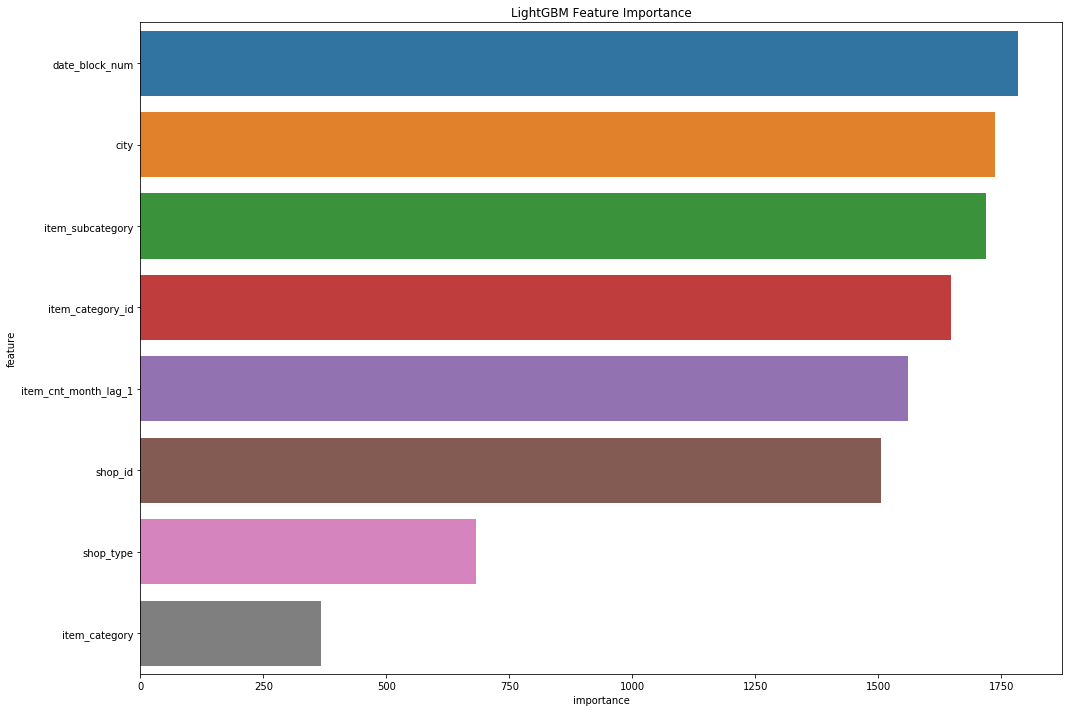

In [50]:
df_fimp = pd.DataFrame()
df_fimp["feature"] = X_train.columns.values
df_fimp["importance"] = impor1


plt.figure(figsize=(15, 10))
sns.barplot(x="importance", y="feature", data=df_fimp.sort_values(by="importance", ascending=False))
plt.title("LightGBM Feature Importance")
plt.tight_layout()

In [48]:
submission = pd.DataFrame({
    "ID": test_df.index, 
    "item_cnt_month": y_final_test
})
submission.to_csv('submission_no_features.csv', index=False)

LB Score = 1.0

So, one can get slightly worse results (~10% lower rmse) by using only the value of the target variable in the previous month and some other readily available features, thus avoiding the tedious process of feature engineering.